<a href="https://colab.research.google.com/github/sohailNaseemKhan10/Rock_Paper_Scissor-Game/blob/main/Student_performance_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
# Load dataset
df = pd.read_csv('/content/exams.csv')

# Display first 5 rows
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group D,some college,standard,completed,59,70,78
1,male,group D,associate's degree,standard,none,96,93,87
2,female,group D,some college,free/reduced,none,57,76,77
3,male,group B,some college,free/reduced,none,70,70,63
4,female,group D,associate's degree,standard,none,83,85,86


In [ ]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:\n", df.columns)

# Data types
print("\nData Types:\n")
print(df.dtypes)

Dataset Shape: (1000, 8)

Columns:
 Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

Data Types:

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object


In [ ]:
# Missing values
missing_values = df.isnull().sum()

print("Missing Values:\n")
print(missing_values)

Missing Values:

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [ ]:
# Statistical summary
df.describe()

,math score,reading score,writing score
count,1000.000000,1000.000000,1000.000000
mean,67.810000,70.382000,69.140000
std,15.250196,14.107413,15.025917
min,15.000000,25.000000,15.000000
25%,58.000000,61.000000,59.000000
50%,68.000000,70.500000,70.000000
75%,79.250000,80.000000,80.000000
max,100.000000,100.000000,100.000000


In [ ]:
# Duplicate rows
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [ ]:
# Unique values count
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

gender: 2 unique values
race/ethnicity: 5 unique values
parental level of education: 6 unique values
lunch: 2 unique values
test preparation course: 2 unique values
math score: 79 unique values
reading score: 71 unique values
writing score: 74 unique values


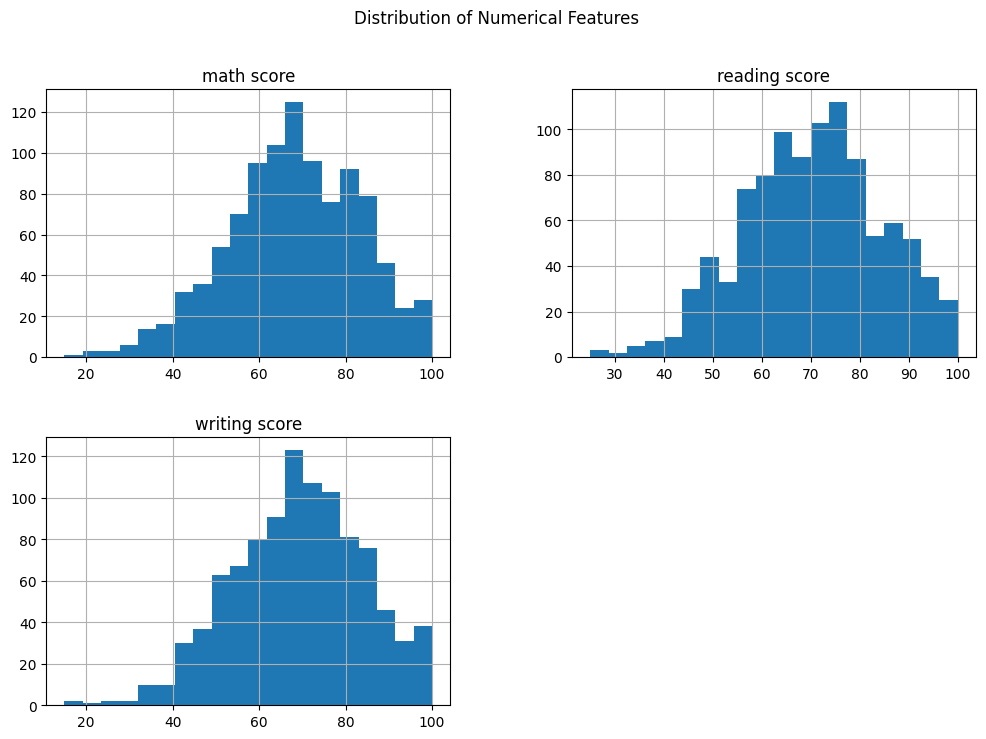

In [ ]:
# Numerical columns
num_cols = df.select_dtypes(include=np.number).columns

# Plot histograms
df[num_cols].hist(figsize=(12,8), bins=20)

plt.suptitle("Distribution of Numerical Features")
plt.show()

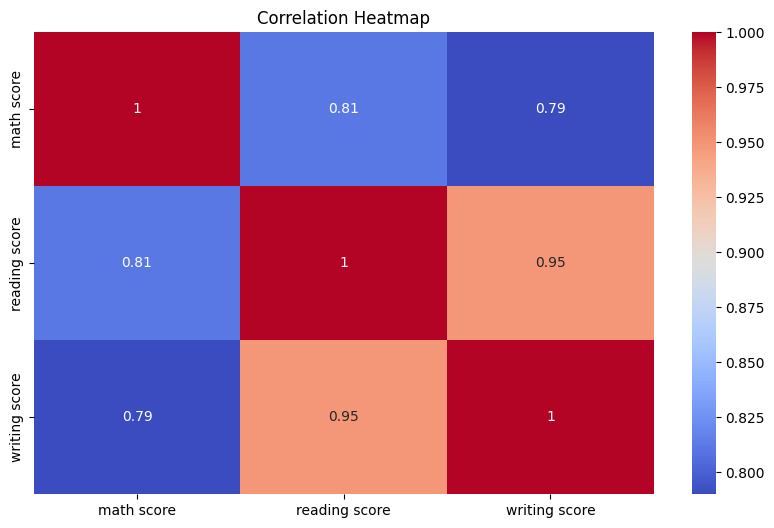

In [ ]:
# Correlation matrix
corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Average scores by gender
gender_scores = df.groupby('gender')[['math score', 'reading score', 'writing score']].mean()

print(gender_scores)

        math score  reading score  writing score
gender                                          
female    64.77439      73.473577      73.439024
male      70.75000      67.387795      64.976378


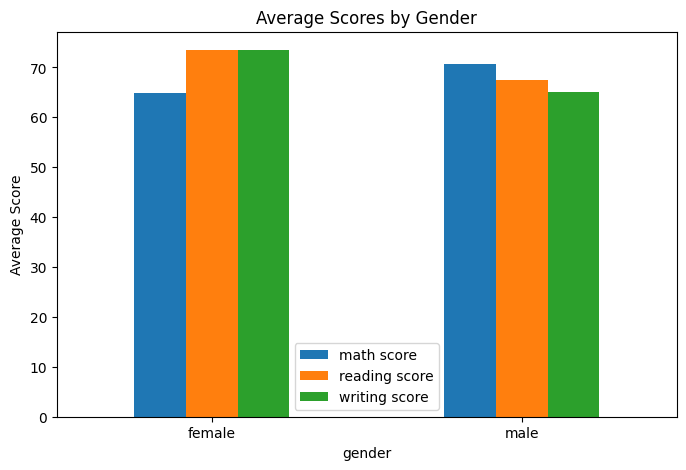

In [ ]:
gender_scores.plot(kind='bar', figsize=(8,5))

plt.title("Average Scores by Gender")
plt.ylabel("Average Score")
plt.xticks(rotation=0)

plt.show()

In [ ]:
# Average scores by parental education
parent_edu = df.groupby('parental level of education')[['math score', 'reading score', 'writing score']].mean()

parent_edu

,math score,reading score,writing score
parental level of education,,,
associate's degree,70.348039,72.647059,72.039216
bachelor's degree,69.866667,71.819048,72.266667
high school,65.381395,69.223256,66.772093
master's degree,71.026667,71.973333,71.746667
some college,68.642857,70.941964,69.473214
some high school,64.197740,66.943503,65.293785


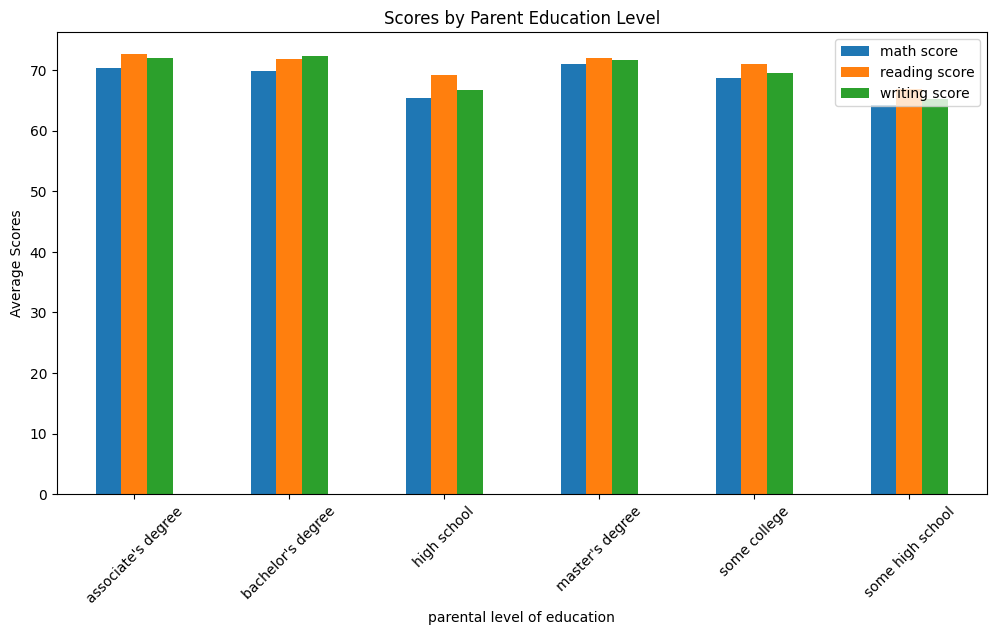

In [ ]:
parent_edu.plot(kind='bar', figsize=(12,6))

plt.title("Scores by Parent Education Level")
plt.ylabel("Average Scores")
plt.xticks(rotation=45)

plt.show()

In [ ]:
# Average scores by lunch type
lunch_scores = df.groupby('lunch')[['math score', 'reading score', 'writing score']].mean()

print(lunch_scores)

              math score  reading score  writing score
lunch                                                 
free/reduced   59.900000      65.641176      64.235294
standard       71.884848      72.824242      71.666667


In [ ]:
# Test preparation course impact
prep_scores = df.groupby('test preparation course')[['math score', 'reading score', 'writing score']].mean()

print(prep_scores)

                         math score  reading score  writing score
test preparation course                                          
completed                 70.334302      74.726744      75.808140
none                      66.486280      68.103659      65.643293


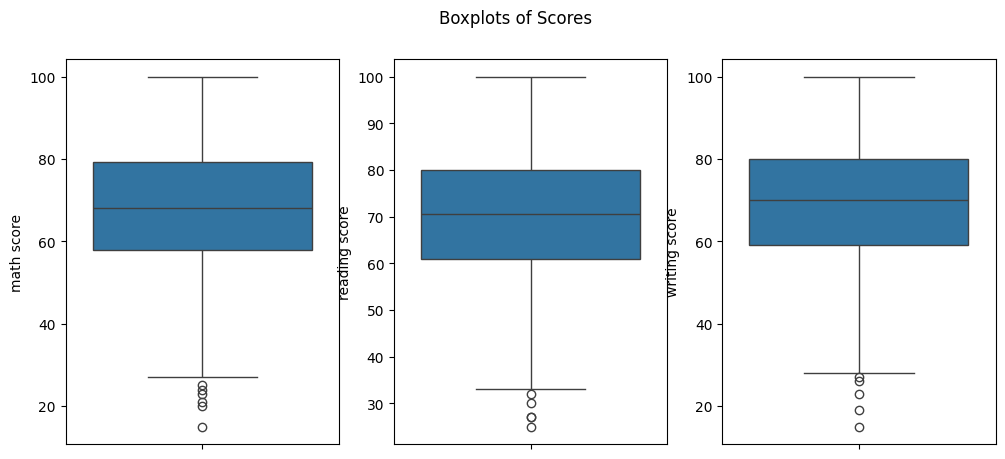

In [ ]:
# Boxplots
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
sns.boxplot(y=df['math score'])

plt.subplot(1,3,2)
sns.boxplot(y=df['reading score'])

plt.subplot(1,3,3)
sns.boxplot(y=df['writing score'])

plt.suptitle("Boxplots of Scores")

plt.show()

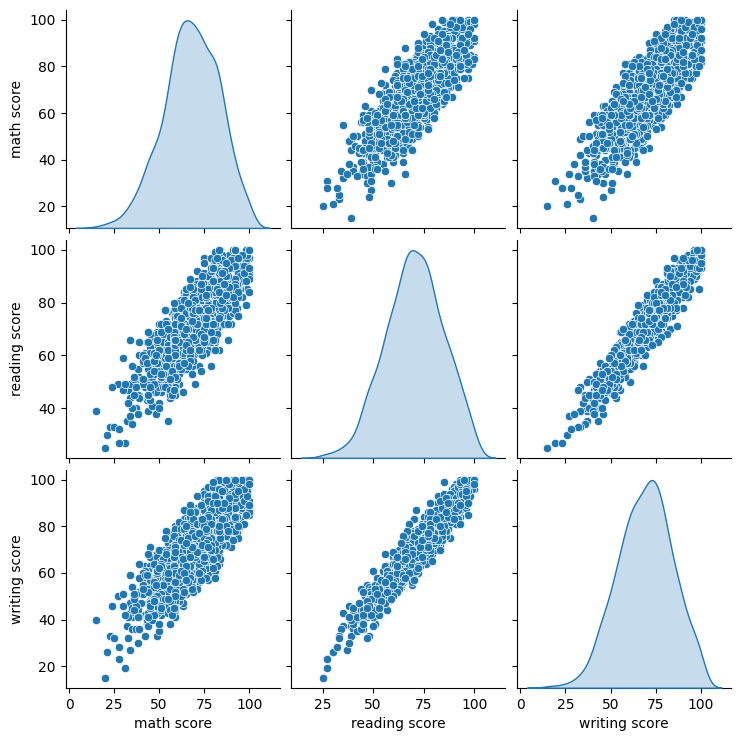

In [ ]:
# Pairplot
sns.pairplot(df[['math score', 'reading score', 'writing score']],
             diag_kind='kde')

plt.show()

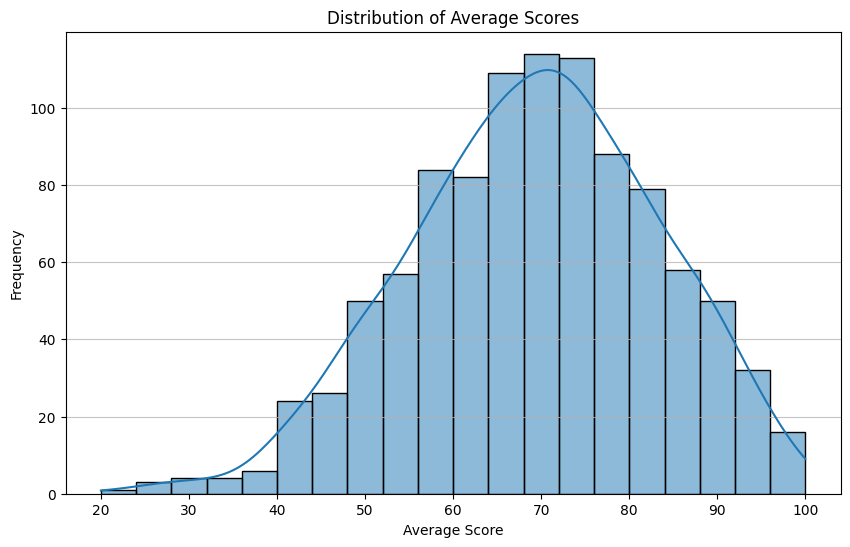

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['average_score'], bins=20, kde=True)
plt.title('Distribution of Average Scores')
plt.xlabel('Average Score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
# Create average score column
df['average_score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
) / 3

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group D,some college,standard,completed,59,70,78,69.000000
1,male,group D,associate's degree,standard,none,96,93,87,92.000000
2,female,group D,some college,free/reduced,none,57,76,77,70.000000
3,male,group B,some college,free/reduced,none,70,70,63,67.666667
4,female,group D,associate's degree,standard,none,83,85,86,84.666667


In [ ]:
# Create average score column
df['average_score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
) / 3

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group D,some college,standard,completed,59,70,78,69.000000
1,male,group D,associate's degree,standard,none,96,93,87,92.000000
2,female,group D,some college,free/reduced,none,57,76,77,70.000000
3,male,group B,some college,free/reduced,none,70,70,63,67.666667
4,female,group D,associate's degree,standard,none,83,85,86,84.666667


In [ ]:
# Create performance category
def performance(avg):
    if avg >= 80:
        return 'Excellent'
    elif avg >= 60:
        return 'Good'
    elif avg >= 40:
        return 'Average'
    else:
        return 'Poor'

df['performance_category'] = df['average_score'].apply(performance)

df.head()
df[['math score', 'reading score', 'writing score', 'average_score']].head()

,math score,reading score,writing score,average_score
0,59,70,78,69.000000
1,96,93,87,92.000000
2,57,76,77,70.000000
3,70,70,63,67.666667
4,83,85,86,84.666667


In [ ]:
# Create performance category
def performance(avg):
    if avg >= 80:
        return 'Excellent'
    elif avg >= 60:
        return 'Good'
    elif avg >= 40:
        return 'Average'
    else:
        return 'Poor'

df['performance_category'] = df['average_score'].apply(performance)

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,performance_category
0,female,group D,some college,standard,completed,59,70,78,69.000000,Good
1,male,group D,associate's degree,standard,none,96,93,87,92.000000,Excellent
2,female,group D,some college,free/reduced,none,57,76,77,70.000000,Good
3,male,group B,some college,free/reduced,none,70,70,63,67.666667,Good
4,female,group D,associate's degree,standard,none,83,85,86,84.666667,Excellent


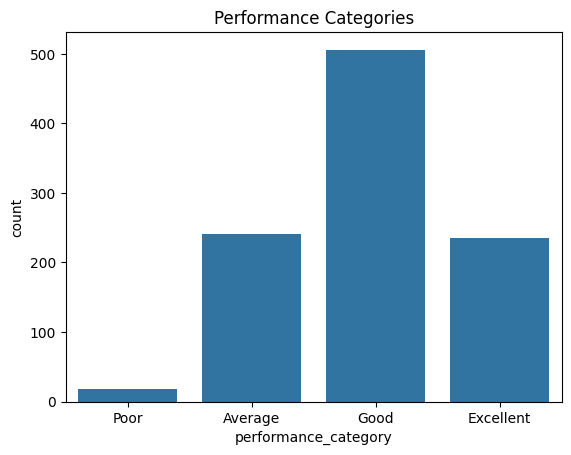

In [ ]:
# Countplot for performance categories
sns.countplot(x='performance_category', data=df,
              order=['Poor', 'Average', 'Good', 'Excellent'])

plt.title("Performance Categories")
plt.show()

In [ ]:
print("EDA COMPLETED SUCCESSFULLY")

print("\nKey Insights:")
print("1. Reading and writing scores are usually highly correlated.")
print("2. Students completing test preparation perform better.")
print("3. Parent education level impacts student scores.")
print("4. Students with standard lunch often score higher.")
print("5. Gender differences can be observed in subject performance.")

EDA COMPLETED SUCCESSFULLY

Key Insights:
1. Reading and writing scores are usually highly correlated.
2. Students completing test preparation perform better.
3. Parent education level impacts student scores.
4. Students with standard lunch often score higher.
5. Gender differences can be observed in subject performance.


### Data Preparation for Modeling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define features (X) and target (y)
# Include 'reading score' and 'writing score' as features to potentially improve prediction,
# but exclude 'performance_category', 'average_score', and 'math score' to prevent data leakage
X = df.drop(['performance_category', 'average_score', 'math score'], axis=1)
y = df['performance_category']

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=np.number).columns

# Create a column transformer for one-hot encoding categorical features and passing through numerical features
transformers = [
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
]
# Add numerical features to the transformer if they exist
if len(numerical_features) > 0:
    transformers.append(('num', 'passthrough', numerical_features))

preprocessor = ColumnTransformer(transformers, remainder='drop') # 'remainder=drop' ensures only specified features are used

# Apply preprocessing
X_processed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding and passthrough
categorical_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(categorical_feature_names) + list(numerical_features)
X_df_processed = pd.DataFrame(X_processed.toarray(), columns=all_feature_names) # Convert sparse matrix to dense array

# Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_df_processed, y, test_size=0.2, random_state=42, stratify=y
)

print("Data split into training and testing sets successfully:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

display(X_train.head())

AttributeError: 'numpy.ndarray' object has no attribute 'toarray'

### Re-training and Re-evaluating the Decision Tree Classifier (after addressing data leakage)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Initialize the Decision Tree Classifier
dtc_re_trained = DecisionTreeClassifier(random_state=42)

# Train the model with the updated X_train and y_train
dtc_re_trained.fit(X_train, y_train)

print("Decision Tree Classifier re-trained successfully with corrected features!")

# Make predictions on the test set
y_pred_re_trained = dtc_re_trained.predict(X_test)

# Evaluate the model
accuracy_re_trained = accuracy_score(y_test, y_pred_re_trained)
precision_re_trained = precision_score(y_test, y_pred_re_trained, average='weighted')
recall_re_trained = recall_score(y_test, y_pred_re_trained, average='weighted')
f1_re_trained = f1_score(y_test, y_pred_re_trained, average='weighted')

print(f"\nAccuracy (re-trained model): {accuracy_re_trained:.4f}")
print(f"Precision (re-trained model): {precision_re_trained:.4f}")
print(f"Recall (re-trained model): {recall_re_trained:.4f}")
print(f"F1-Score (re-trained model): {f1_re_trained:.4f}")

print("\nClassification Report (re-trained model):")
print(classification_report(y_test, y_pred_re_trained))

NameError: name 'X_train' is not defined

### Hyperparameter Tuning for Decision Tree Classifier

Now that we have a more realistic baseline, let's try to improve the Decision Tree Classifier's performance by tuning its hyperparameters using `GridSearchCV`. This will explore different combinations of parameters to find the best performing model.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Define the parameter grid to search
param_grid = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5, # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Get the best estimator
best_dt_classifier = grid_search.best_estimator_

# Make predictions on the test set with the best model
y_pred_best_dt = best_dt_classifier.predict(X_test)

# Evaluate the best model
accuracy_best_dt = accuracy_score(y_test, y_pred_best_dt)
precision_best_dt = precision_score(y_test, y_pred_best_dt, average='weighted')
recall_best_dt = recall_score(y_test, y_pred_best_dt, average='weighted')
f1_best_dt = f1_score(y_test, y_pred_best_dt, average='weighted')

print(f"\nAccuracy (Tuned Decision Tree): {accuracy_best_dt:.4f}")
print(f"Precision (Tuned Decision Tree): {precision_best_dt:.4f}")
print(f"Recall (Tuned Decision Tree): {recall_best_dt:.4f}")
print(f"F1-Score (Tuned Decision Tree): {f1_best_dt:.4f}")

print("\nClassification Report (Tuned Decision Tree):")
print(classification_report(y_test, y_pred_best_dt))

NameError: name 'X_train' is not defined

### Model Training: Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train)

print("Random Forest Classifier trained successfully!")

Random Forest Classifier trained successfully!


In [ ]:
# Make predictions on the test set
y_pred_rf = rf_classifier.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print(f"Accuracy (Random Forest): {accuracy_rf:.4f}")
print(f"Precision (Random Forest): {precision_rf:.4f}")
print(f"Recall (Random Forest): {recall_rf:.4f}")
print(f"F1-Score (Random Forest): {f1_rf:.4f}")

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

Accuracy (Random Forest): 0.4750
Precision (Random Forest): 0.4578
Recall (Random Forest): 0.4750
F1-Score (Random Forest): 0.4611

Classification Report (Random Forest):
              precision    recall  f1-score   support

     Average       0.33      0.29      0.31        48
   Excellent       0.47      0.34      0.40        47
        Good       0.53      0.64      0.58       101
        Poor       0.00      0.00      0.00         4

    accuracy                           0.47       200
   macro avg       0.33      0.32      0.32       200
weighted avg       0.46      0.47      0.46       200



### Hyperparameter Tuning for Random Forest Classifier

Let's also try to improve the Random Forest Classifier's performance by tuning its hyperparameters.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Define the parameter grid to search
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Initialize GridSearchCV for Random Forest
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best parameters found for Random Forest: {grid_search_rf.best_params_}")
print(f"Best cross-validation accuracy for Random Forest: {grid_search_rf.best_score_:.4f}")

# Get the best estimator
best_rf_classifier = grid_search_rf.best_estimator_

# Make predictions on the test set with the best Random Forest model
y_pred_best_rf = best_rf_classifier.predict(X_test)

# Evaluate the best Random Forest model
accuracy_best_rf = accuracy_score(y_test, y_pred_best_rf)
precision_best_rf = precision_score(y_test, y_pred_best_rf, average='weighted')
recall_best_rf = recall_score(y_test, y_pred_best_rf, average='weighted')
f1_best_rf = f1_score(y_test, y_pred_best_rf, average='weighted')

print(f"\nAccuracy (Tuned Random Forest): {accuracy_best_rf:.4f}")
print(f"Precision (Tuned Random Forest): {precision_best_rf:.4f}")
print(f"Recall (Tuned Random Forest): {recall_best_rf:.4f}")
print(f"F1-Score (Tuned Random Forest): {f1_best_rf:.4f}")

print("\nClassification Report (Tuned Random Forest):")
print(classification_report(y_test, y_pred_best_rf))

NameError: name 'X_train' is not defined

### Confusion Matrices for Trained Models

In [ ]:
The Decision Tree Classifier (`dtc_re_trained`) has already been initialized and trained in a previous cell (cell `0b526069`) with corrected features to avoid data leakage. We will proceed to evaluate that model.

Decision Tree Classifier trained successfully!


### Model Evaluation

### Model Accuracy Comparison

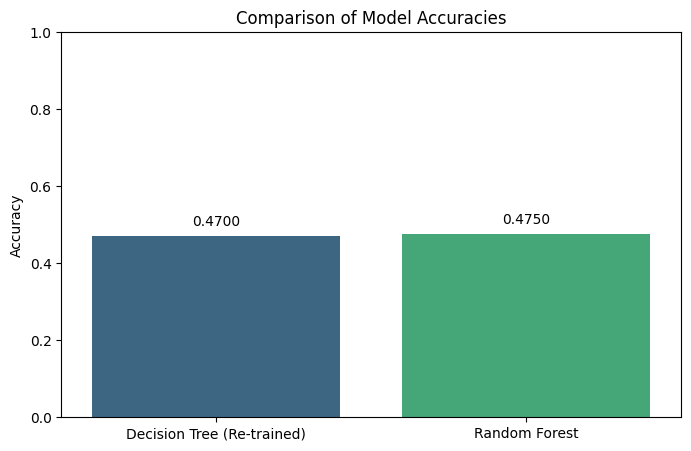

In [ ]:
models = ['Decision Tree (Re-trained)', 'Random Forest']
accuracies = [accuracy_re_trained, accuracy_rf]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.ylim(0, 1.0) # Accuracy ranges from 0 to 1
plt.title('Comparison of Model Accuracies')
plt.ylabel('Accuracy')

for index, value in enumerate(accuracies):
    plt.text(index, value + 0.02, f'{value:.4f}', ha='center', va='bottom')

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

models = ['Decision Tree (Re-trained)', 'Tuned Decision Tree', 'Random Forest', 'Tuned Random Forest']
accuracies = [accuracy_re_trained, accuracy_best_dt, accuracy_rf, accuracy_best_rf]

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.ylim(0, 1.0) # Accuracy ranges from 0 to 1
plt.title('Comparison of Model Accuracies After Tuning')
plt.ylabel('Accuracy')

for index, value in enumerate(accuracies):
    plt.text(index, value + 0.02, f'{value:.4f}', ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

NameError: name 'accuracy_re_trained' is not defined

### Feature Importance Analysis

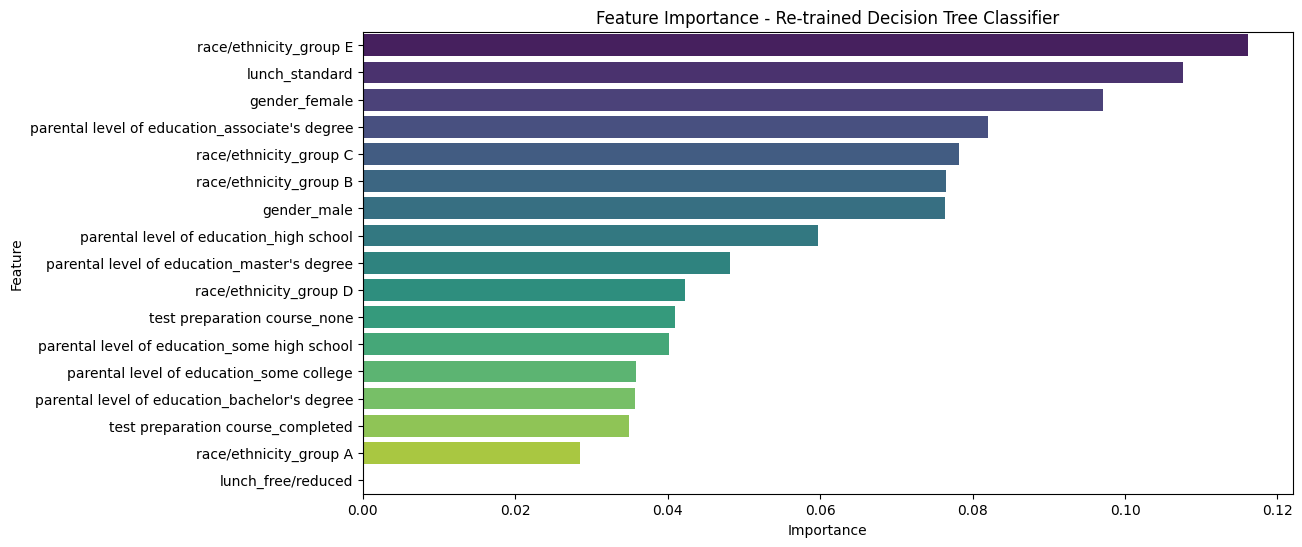

In [ ]:
# Feature Importance for Re-trained Decision Tree Classifier
feature_importances_dt = pd.DataFrame({
    'feature': X_train.columns,
    'importance': dtc_re_trained.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature', data=feature_importances_dt, palette='viridis')
plt.title('Feature Importance - Re-trained Decision Tree Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

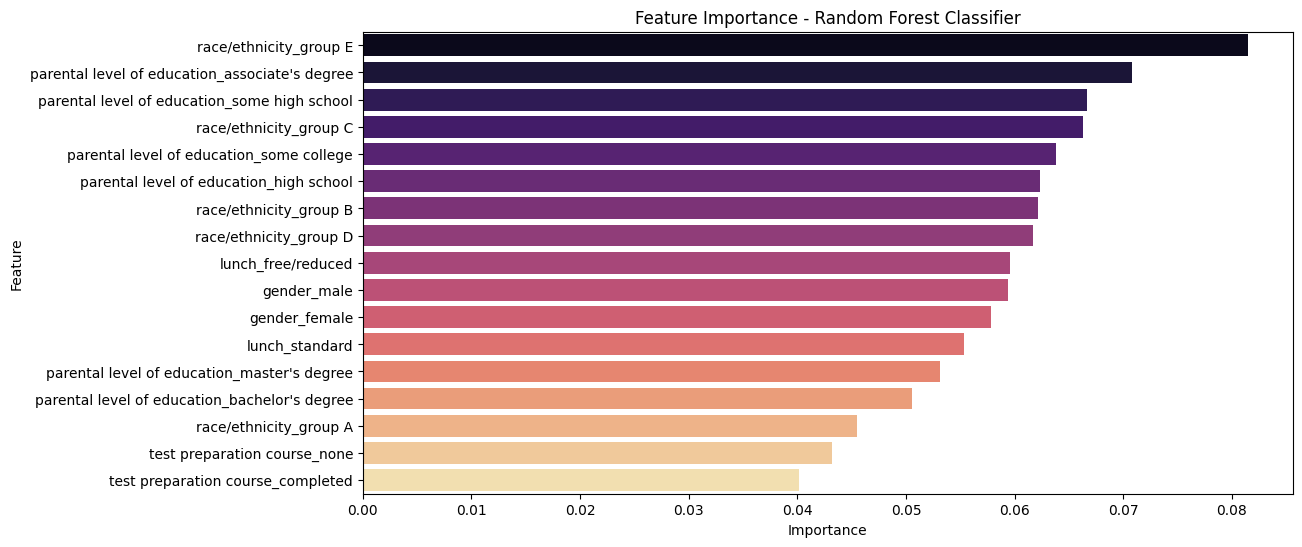

In [ ]:
# Feature Importance for Random Forest Classifier
feature_importances_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_classifier.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature', data=feature_importances_rf, palette='magma')
plt.title('Feature Importance - Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Importance for Tuned Decision Tree Classifier
feature_importances_best_dt = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_dt_classifier.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature', data=feature_importances_best_dt, palette='viridis')
plt.title('Feature Importance - Tuned Decision Tree Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

NameError: name 'X_train' is not defined

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Importance for Tuned Random Forest Classifier
feature_importances_best_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf_classifier.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature', data=feature_importances_best_rf, palette='magma')
plt.title('Feature Importance - Tuned Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

NameError: name 'X_train' is not defined